# McDonald's Profitability Dashboard Analysis Notebook

## Research Question
Did McDonald's long-term revenue growth translate into stronger profitability from 2002 to 2022?

## Intended Users
- Business students
- Potential investors
- Industry analysts
- Users interested in restaurant industry performance

## Project Purpose
This notebook documents the analytical workflow behind the Streamlit dashboard.  
It shows how the dataset was loaded, prepared, analysed, and interpreted using Python.

## Data Source

- **Dataset:** McDonalds_Financial_Statements.csv  
- **Source:** Public McDonald's financial statements dataset from Kaggle  
- **Access date:** 17 April 2026

I selected this dataset because it includes key indicators such as revenue, net income, and operating margin, which allow me to compare business scale, profit performance, and profitability quality over time.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

## 1. Load the Dataset

The dataset is stored in the local `data` folder so that the repository can run after being cloned.

In [2]:
DATA_PATH = Path("data") / "McDonalds_Financial_Statements.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,Year,Market cap ($B),Revenue ($B),Earnings ($B),P/E ratio,P/S ratio,P/B ratio,Operating Margin (%),EPS ($),Shares Outstanding ($B),Cash on Hand ($B),Dividend Yield (%),Dividend (stock split adjusted) ($),Net assets ($B),Total assets ($B),Total debt ($B),Total liabilities ($B)
0,2022,193.01,23.18,7.82,31.30,8.33,-32.20,33.76,8.42,0.73,2.58,2.15,5.66,-6.01,50.43,48.03,56.43
1,2021,200.31,23.22,9.12,26.50,8.63,-43.50,39.31,10.11,0.74,4.70,1.96,5.25,-4.61,53.60,48.64,58.20
2,2020,159.88,19.20,6.14,33.80,8.32,-20.40,31.97,6.35,0.74,3.44,2.35,5.04,-7.83,52.62,48.51,60.45
3,2019,147.47,21.28,8.01,24.80,6.93,-18.00,38.04,7.98,0.74,0.89,2.39,4.73,-8.22,47.51,46.87,55.72
4,2018,136.21,21.02,7.81,23.20,6.48,-21.80,37.17,7.65,0.76,0.86,2.36,4.19,-6.26,32.81,31.07,39.06


## 2. Initial Data Inspection

Before analysis, I check the size, column names, data types, and whether the dataset has missing values.

In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

Shape: (21, 17)

Columns:
['Year', 'Market cap ($B)', 'Revenue ($B)', 'Earnings ($B)', 'P/E ratio', 'P/S ratio', 'P/B ratio', 'Operating Margin (%)', 'EPS ($)', 'Shares Outstanding ($B)', 'Cash on Hand ($B)', 'Dividend Yield (%)', 'Dividend (stock split adjusted) ($)', 'Net assets ($B)', 'Total assets ($B)', 'Total debt ($B)', 'Total liabilities ($B)']

Data types:
Year                                     int64
Market cap ($B)                        float64
Revenue ($B)                           float64
Earnings ($B)                          float64
P/E ratio                              float64
P/S ratio                              float64
P/B ratio                              float64
Operating Margin (%)                   float64
EPS ($)                                float64
Shares Outstanding ($B)                float64
Cash on Hand ($B)                      float64
Dividend Yield (%)                     float64
Dividend (stock split adjusted) ($)    float64
Net assets ($B)      

## 3. Data Quality Checks

This section checks whether the dataset has:
- duplicate rows
- duplicate years
- required columns for the analysis

In [4]:
required_columns = ["Year", "Revenue ($B)", "Earnings ($B)", "Operating Margin (%)"]

missing_required_columns = [col for col in required_columns if col not in df.columns]
duplicate_rows = df.duplicated().sum()
duplicate_years = df["Year"].duplicated().sum() if "Year" in df.columns else None

print("Missing required columns:", missing_required_columns)
print("Duplicate rows:", duplicate_rows)
print("Duplicate years:", duplicate_years)

Missing required columns: []
Duplicate rows: 0
Duplicate years: 0


## 4. Data Preparation

The dataset is already relatively clean, so only light preparation is required:
- standardise column names
- rename one variable for consistency
- sort the data by year
- calculate revenue growth and net income growth

In [5]:
# Standardise column names
df.columns = df.columns.str.strip()

# Rename one variable for consistency
df = df.rename(columns={"Earnings ($B)": "Net Income ($B)"})

# Sort by year
df = df.sort_values("Year").reset_index(drop=True)

# Calculate growth rates
df["Revenue Growth (%)"] = df["Revenue ($B)"].pct_change() * 100
df["Net Income Growth (%)"] = df["Net Income ($B)"].pct_change() * 100

df.head()

,Year,Market cap ($B),Revenue ($B),Net Income ($B),P/E ratio,P/S ratio,P/B ratio,Operating Margin (%),EPS ($),Shares Outstanding ($B),Cash on Hand ($B),Dividend Yield (%),Dividend (stock split adjusted) ($),Net assets ($B),Total assets ($B),Total debt ($B),Total liabilities ($B),Revenue Growth (%),Net Income Growth (%)
0,2002,20.39,15.40,1.66,23.00,1.32,1.98,10.79,0.70,1.27,0.33,1.46,0.24,10.28,23.97,9.97,13.68,NaN,NaN
1,2003,31.33,17.14,2.34,21.40,1.83,2.62,13.69,1.16,1.27,0.49,1.61,0.40,11.98,25.52,9.73,13.54,11.30,40.96
2,2004,40.71,19.06,3.20,17.60,2.14,2.87,16.80,1.82,1.25,1.37,1.72,0.55,14.20,27.83,9.21,13.63,11.20,36.75
3,2005,42.59,20.46,3.70,16.40,2.08,2.81,18.09,2.06,1.25,4.26,1.99,0.67,15.14,29.98,10.14,14.84,7.35,15.62
4,2006,53.36,20.81,3.88,15.40,2.56,3.45,19.30,2.88,1.23,2.13,2.26,1.00,15.45,29.02,8.43,13.56,1.71,4.86


## 5. Prepared Data Check

After preparation, I check the cleaned dataset again to confirm that the structure is suitable for analysis.

In [6]:
print("Prepared shape:", df.shape)

print("\nMissing values after preparation:")
print(df.isna().sum())

df.describe().T

Prepared shape: (21, 19)

Missing values after preparation:
Year                                   0
Market cap ($B)                        0
Revenue ($B)                           0
Net Income ($B)                        0
P/E ratio                              0
P/S ratio                              0
P/B ratio                              0
Operating Margin (%)                   0
EPS ($)                                0
Shares Outstanding ($B)                0
Cash on Hand ($B)                      0
Dividend Yield (%)                     0
Dividend (stock split adjusted) ($)    0
Net assets ($B)                        0
Total assets ($B)                      0
Total debt ($B)                        0
Total liabilities ($B)                 0
Revenue Growth (%)                     1
Net Income Growth (%)                  1
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Year,21.00,2012.00,6.20,2002.00,2007.00,2012.00,2017.00,2022.00
Market cap ($B),21.00,96.82,50.40,20.39,67.22,90.22,136.21,200.31
Revenue ($B),21.00,22.71,3.40,15.40,20.81,22.82,24.62,28.10
Net Income ($B),21.00,6.21,2.23,1.66,3.88,6.86,8.01,9.12
P/E ratio,21.00,21.66,5.54,15.00,16.50,21.40,24.80,33.80
P/S ratio,21.00,4.23,2.27,1.32,2.95,3.36,6.01,8.63
P/B ratio,21.00,-7.10,19.36,-45.90,-20.40,2.87,5.53,15.10
Operating Margin (%),21.00,26.89,8.36,10.79,19.30,28.52,31.97,39.31
EPS ($),21.00,4.85,2.51,0.70,2.88,4.88,6.35,10.11
Shares Outstanding ($B),21.00,0.99,0.20,0.73,0.79,1.00,1.18,1.27


## 6. Summary Metrics

This section calculates several key indicators that are also useful in the dashboard:
- highest and lowest revenue year
- highest and lowest net income year
- highest and lowest operating margin year
- overall changes across the full period
- average growth rates

In [8]:
latest_row = df.iloc[-1]
earliest_row = df.iloc[0]

highest_revenue_row = df.loc[df["Revenue ($B)"].idxmax()]
lowest_revenue_row = df.loc[df["Revenue ($B)"].idxmin()]

highest_income_row = df.loc[df["Net Income ($B)"].idxmax()]
lowest_income_row = df.loc[df["Net Income ($B)"].idxmin()]

highest_margin_row = df.loc[df["Operating Margin (%)"].idxmax()]
lowest_margin_row = df.loc[df["Operating Margin (%)"].idxmin()]

revenue_change = latest_row["Revenue ($B)"] - earliest_row["Revenue ($B)"]
income_change = latest_row["Net Income ($B)"] - earliest_row["Net Income ($B)"]
margin_change = latest_row["Operating Margin (%)"] - earliest_row["Operating Margin (%)"]

avg_revenue_growth = df["Revenue Growth (%)"].dropna().mean()
avg_income_growth = df["Net Income Growth (%)"].dropna().mean()

summary_metrics = pd.DataFrame({
    "Metric": [
        "Highest Revenue Year",
        "Lowest Revenue Year",
        "Highest Net Income Year",
        "Lowest Net Income Year",
        "Highest Operating Margin Year",
        "Lowest Operating Margin Year",
        "Revenue Change ($B)",
        "Net Income Change ($B)",
        "Operating Margin Change (pts)",
        "Average Revenue Growth (%)",
        "Average Net Income Growth (%)"
    ],
    "Value": [
        int(highest_revenue_row["Year"]),
        int(lowest_revenue_row["Year"]),
        int(highest_income_row["Year"]),
        int(lowest_income_row["Year"]),
        int(highest_margin_row["Year"]),
        int(lowest_margin_row["Year"]),
        revenue_change,
        income_change,
        margin_change,
        avg_revenue_growth,
        avg_income_growth
    ]
})

summary_metrics

,Metric,Value
0,Highest Revenue Year,2013.00
1,Lowest Revenue Year,2002.00
2,Highest Net Income Year,2021.00
3,Lowest Net Income Year,2002.00
4,Highest Operating Margin Year,2021.00
5,Lowest Operating Margin Year,2002.00
6,Revenue Change ($B),7.78
7,Net Income Change ($B),6.16
8,Operating Margin Change (pts),22.97
9,Average Revenue Growth (%),2.36


## 7. Revenue Trend

This chart shows how McDonald's business scale changed over time.

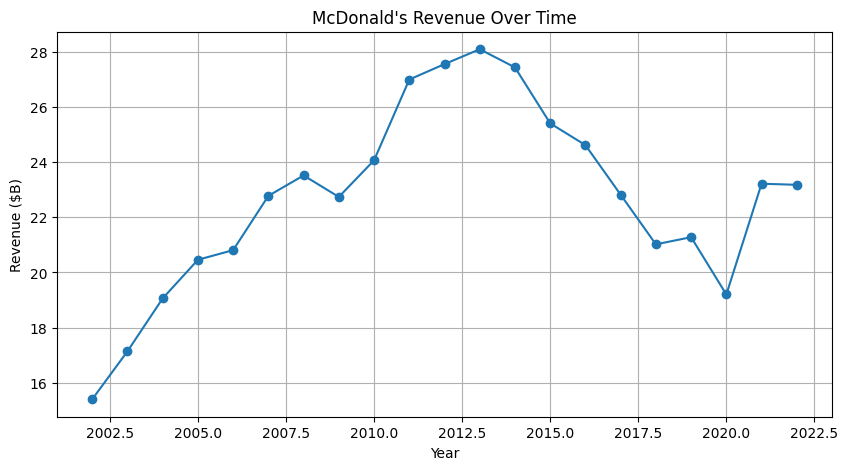

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(df["Year"], df["Revenue ($B)"], marker="o")
plt.title("McDonald's Revenue Over Time")
plt.xlabel("Year")
plt.ylabel("Revenue ($B)")
plt.grid(True)
plt.show()

### Interpretation
Revenue changed substantially over the selected period rather than growing at a perfectly steady pace. This suggests that McDonald's business scale expanded over time, but revenue alone should not be treated as a complete indicator of business quality.

## 8. Net Income Trend

This chart shows how McDonald's profit performance changed over time.

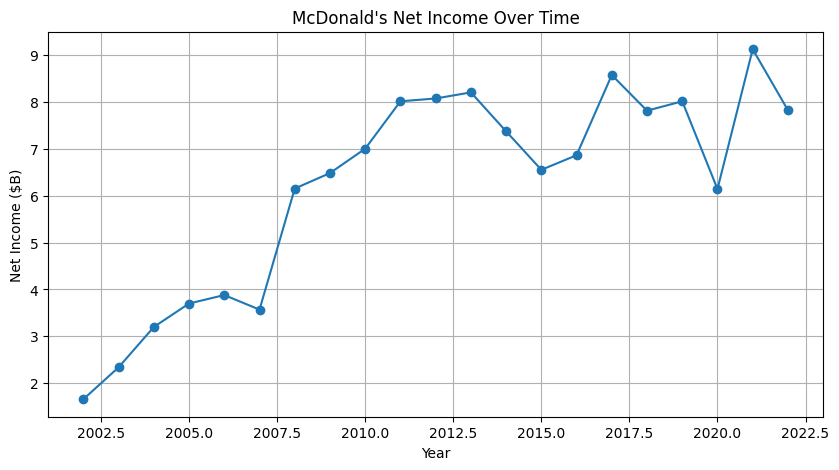

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(df["Year"], df["Net Income ($B)"], marker="o")
plt.title("McDonald's Net Income Over Time")
plt.xlabel("Year")
plt.ylabel("Net Income ($B)")
plt.grid(True)
plt.show()

### Interpretation
Net income was more volatile than revenue. This means that sales growth did not always translate into equally stable profit growth, so investors and students should not assume that larger sales automatically mean stronger financial performance.

## 9. Operating Margin Trend

This chart shows whether McDonald's became more effective at converting sales into profit.

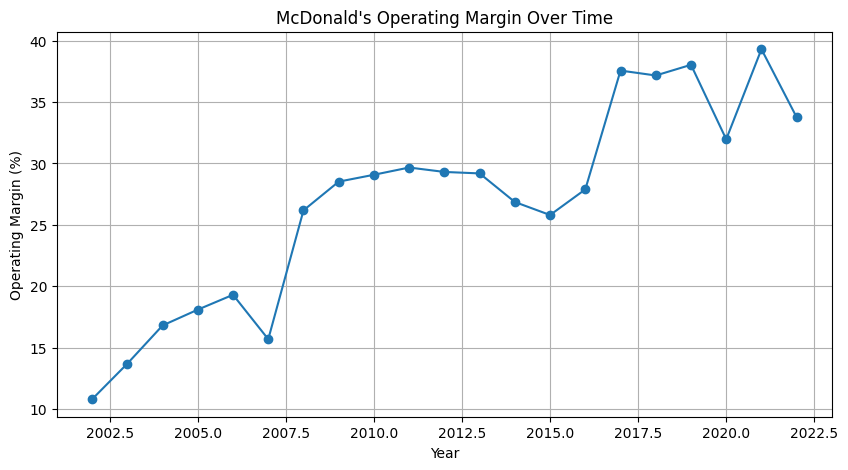

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(df["Year"], df["Operating Margin (%)"], marker="o")
plt.title("McDonald's Operating Margin Over Time")
plt.xlabel("Year")
plt.ylabel("Operating Margin (%)")
plt.grid(True)
plt.show()

### Interpretation
Operating margin changed across the selected period, which suggests that profitability quality did not move perfectly with business size. This is important because efficiency should be evaluated separately from revenue growth.

## 10. Revenue vs Net Income Comparison

This comparison helps assess whether business scale and profit performance moved in the same way over time.

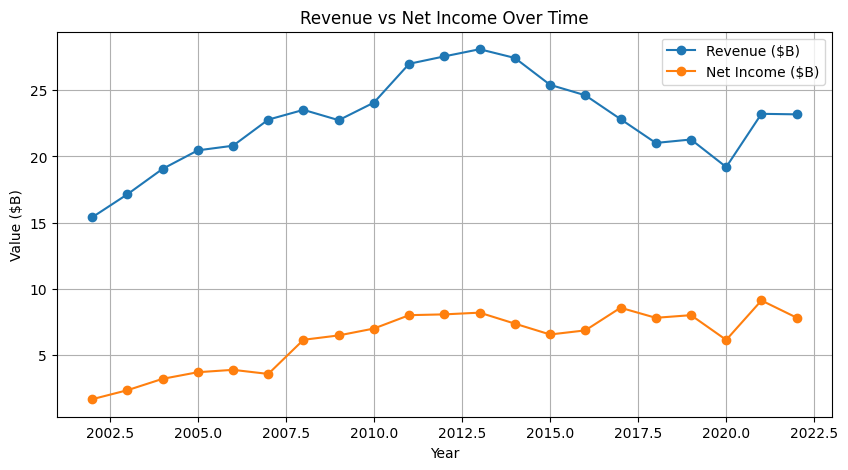

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(df["Year"], df["Revenue ($B)"], marker="o", label="Revenue ($B)")
plt.plot(df["Year"], df["Net Income ($B)"], marker="o", label="Net Income ($B)")
plt.title("Revenue vs Net Income Over Time")
plt.xlabel("Year")
plt.ylabel("Value ($B)")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation
Revenue and net income did not always move at the same pace. This suggests that the year with the highest sales was not necessarily the year with the strongest profit outcome.

## 11. Revenue Growth vs Net Income Growth

This comparison helps evaluate whether growth in business scale was matched by growth in profit performance.

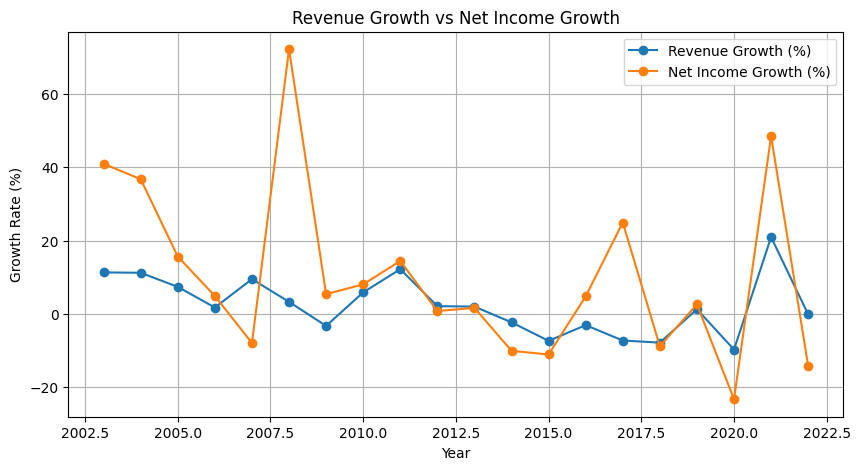

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(df["Year"], df["Revenue Growth (%)"], marker="o", label="Revenue Growth (%)")
plt.plot(df["Year"], df["Net Income Growth (%)"], marker="o", label="Net Income Growth (%)")
plt.title("Revenue Growth vs Net Income Growth")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation
Revenue growth and net income growth did not always move at the same speed. This means that expansion and profitability were not improving consistently in every year.

## 12. Period Comparison

To add a stronger comparison logic, I divide the period into two phases:
- 2002–2011
- 2012–2022

This helps compare whether McDonald's average performance changed across different periods.

In [14]:
period_1 = df[df["Year"] <= 2011]
period_2 = df[df["Year"] >= 2012]

period_comparison = pd.DataFrame({
    "Period": ["2002-2011", "2012-2022"],
    "Average Revenue ($B)": [period_1["Revenue ($B)"].mean(), period_2["Revenue ($B)"].mean()],
    "Average Net Income ($B)": [period_1["Net Income ($B)"].mean(), period_2["Net Income ($B)"].mean()],
    "Average Operating Margin (%)": [period_1["Operating Margin (%)"].mean(), period_2["Operating Margin (%)"].mean()]
})

period_comparison

,Period,Average Revenue ($B),Average Net Income ($B),Average Operating Margin (%)
0,2002-2011,21.30,4.60,20.78
1,2012-2022,23.99,7.68,32.44


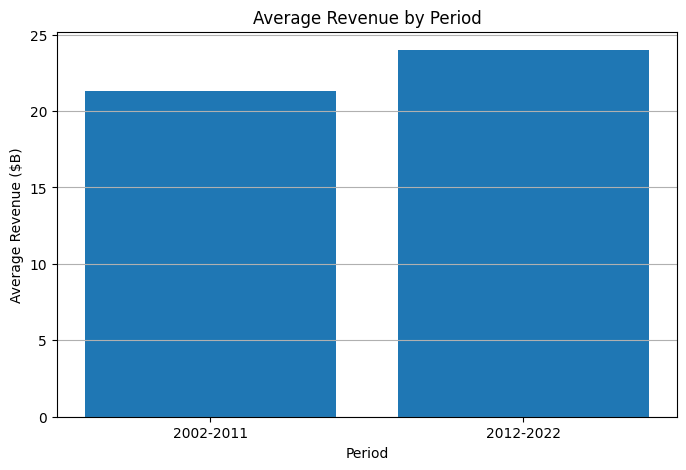

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(period_comparison["Period"], period_comparison["Average Revenue ($B)"])
plt.title("Average Revenue by Period")
plt.xlabel("Period")
plt.ylabel("Average Revenue ($B)")
plt.grid(True, axis="y")
plt.show()

### Interpretation
The period comparison shows whether McDonald's average performance pattern changed across phases rather than only across individual years. This is useful because long-term business quality can often be clearer when performance is compared across broader periods.

## 13. Main Findings

This notebook analysis suggests the following:

1. McDonald's revenue changed substantially over time rather than growing at a perfectly steady pace.
2. Net income was more volatile than revenue, which means that higher sales did not always produce equally stable profit growth.
3. The year with the highest revenue was not necessarily the year with the strongest profit performance.
4. Operating margin changed over time, showing that profitability quality did not move perfectly with business scale.
5. Revenue, net income, and operating margin should be interpreted together rather than in isolation.

## 14. Limitations

This analysis has several limitations:

- It focuses on one company only and does not include competitor comparison.
- It depends on the quality and completeness of the public dataset.
- It does not directly model external business events such as economic shocks or strategy changes.
- It uses selected financial indicators rather than a full valuation model.

## 15. Conclusion

This notebook demonstrates the analytical workflow behind the Streamlit dashboard. It shows that McDonald's revenue growth should not be interpreted alone. A more meaningful evaluation of long-term business performance requires revenue, net income, and operating margin to be considered together.